In [2]:
import os
import torch
import torchvision
import torch.nn.functional as F
from utils.dataset import Dataset
from fr_models.get_model import getmodel
from tqdm import tqdm
from AdvFaceGAN import Generator
from torchmetrics.functional import structural_similarity_index_measure as ssim
from torchmetrics.functional import peak_signal_noise_ratio as psnr
from fr_models.config import threshold_lfw
import numpy as np
import pickle

# 非需要不加载数据集
def prepDataset(test_set, test_batch_size):
    if test_set is not None:
        return test_set
    print("---------------------Load test set-----------------------")
    test_set = Dataset("C:/yy/datasets/CASIA-WebFace/casia-aligned-112x112/")
    print("------------------start batch queue----------------------")
    test_set.start_batch_queue(
        test_batch_size,
        batch_format="random_samples",
        transforms=torchvision.transforms.Compose([
            torchvision.transforms.Resize((112,112)),  # 调整图片大小
            torchvision.transforms.ToTensor(),  # 图片转为Tensor [0,1]
            torchvision.transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # 归一化
        ]),
        num_threads=3,
    )
    return test_set

# 存储评估结果
evaluation_results = {}
test_model_dirs = [
    'target 1 8白盒 无stloss',
    'target 2 8白盒 无stloss',
    'target 3 8白盒 无stloss',
    'target 4 8白盒 无stloss',
    'target 5 8白盒 无stloss',
    'target 6 8白盒 无stloss',
    'target 7 8白盒 无stloss',
    'target 8 8白盒 无stloss',
    
   'target 4 8白盒 奇怪ssim 93ssim',
    'target 4 8白盒 奇怪ssim 93ssim',
   'target 4 8白盒 奇怪ssim 97ssim',
   'target 4 7白盒 奇怪ssim 100ssim',
   'target 5 8白盒 92ssim',
    'target 5 8白盒 92ssim',
   'target 5 8白盒 奇怪ssim 95ssim',
    'target 5 8白盒 奇怪ssim 95ssim',
   'target 8 8白盒 90ssim',
   'target 8 8白盒 奇怪ssim 92ssim',
    
   'target 5 8白盒 无stloss 双身份损失0.15',
    'target 5 8白盒 无stloss 双身份损失0.15',
   'target 8 8白盒 奇怪ssim 90ssim 双身份损失0.2',
   'target 8 8白盒 91ssim 双身份损失0.3',
    
    'target 5 1白盒 92ssim 原始身份损失0.15',
    'target 5 4白盒 92ssim 原始身份损失0.15',
    'target 5 5白盒 92ssim 原始身份损失0.15',
    'target 5 6白盒 92ssim 原始身份损失0.15',
    'target 5 7白盒 92ssim 原始身份损失0.15',
    'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15',
    'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15',
    'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15',
    'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15',
]
test_epoch_ids = [990,990,990,990,990,990,990,990, 990,1490,990,990,1160,990,990,1660,990,1490, 990,1110,990,990, 1490,1490,1490,1490,1490,990,1490,2490,3440]

test_batch_size = 30
# 懒加载
test_set=None
# 添加新fr模型后请把save_path下的pkl都删掉再运行一遍
target_model_name_list = ['CosFace',
                         'SphereFace',
                         'MobileFace',
                         'FaceNet-VGGFace2',
                         'ArcFace',
                         'ResNet50',
                         'IR50-PGDSoftmax',
                         'IR50-TradesCosFace',
                         # 'IR50-Softmax-BR',
                         # 'IR50-Softmax-JPEG',
                         # 'IR50-Softmax-RP',
                         'testir152',]
with torch.no_grad():
    # 遍历每个攻击模型
    for model_idx, (model_dir, epoch_id) in enumerate(zip(test_model_dirs, test_epoch_ids)):
        save_path = f"./data/temp/{model_dir} {epoch_id}.pkl"
        # 检查结果文件是否存在
        if os.path.exists(save_path):
            print(f"结果文件 {save_path} 已存在，正在加载数据...")
            # 加载保存的 pickle 数据
            with open(save_path, 'rb') as pickle_file:
                evaluation_results[f'{model_dir} {epoch_id}'] = pickle.load(pickle_file)
            print(f"结果文件 {save_path} 已加载")
        else:
            print(f"Loading attack model: {model_dir}, epoch {epoch_id}")
            fake_generator = Generator(is_target=True).eval().cuda()
            model_generator_dict = torch.load('./save_dir/'+model_dir +'/model/'+ '%05d_generator.pth' % epoch_id, weights_only=False)
            fake_generator.load_state_dict(model_generator_dict)
            print("---------------------------------------------------------")
            print(f"Evaluating attack model {model_dir} {epoch_id}")
            print("---------------------------------------------------------")
            evaluation_results[f'{model_dir} {epoch_id}']={}
            
            # 遍历目标模型
            for frmodel_name in target_model_name_list:
                print(f"-----------------start evaluate {frmodel_name}-------------------")
                th = threshold_lfw[frmodel_name]['cos']
                ssim_scores = []
                psnr_scores = []
                mse_scores = []
                true_perts_score = []
                FAR_simi_scores = []
                TAR_simi_scores = []
                source_simi_scores = []
                target_simi_scores = []
                source2_simi_scores = []
                source3_simi_scores = []
                target2_simi_scores = []
                target3_simi_scores = []
                frmodel, img_shape = getmodel(frmodel_name)
                test_epoch_size = 6000 // test_batch_size
                for _ in tqdm(range(test_epoch_size)):
                    # get batch data
                    test_set=prepDataset(test_set, test_batch_size)
                    batch = test_set.pop_batch_queue()
                    # Call the generator to generate adversary faces
                    source_faces = batch['sources'].cuda()
                    source2_faces = batch['sources2'].cuda()
                    source3_faces = batch['sources3'].cuda()
                    target_faces = batch['targets'].cuda()
                    target2_faces = batch['targets2'].cuda()
                    target3_faces = batch['targets3'].cuda()
                    perts, fake_afters = fake_generator(sources=source_faces, targets=target_faces)
                    # calculate visual quality metric
                    source_faces = (source_faces * 0.5 + 0.5)*255
                    source2_faces = (source2_faces * 0.5 + 0.5)*255
                    source3_faces = (source3_faces * 0.5 + 0.5)*255
                    target_faces = (target_faces * 0.5 + 0.5)*255
                    target2_faces = (target2_faces * 0.5 + 0.5)*255
                    target3_faces = (target3_faces * 0.5 + 0.5)*255
                    fake_afters = (fake_afters * 0.5 + 0.5)*255
                    for i in range(source_faces.size(0)):  # 遍历 batch 中的每一对图像
                        source = source_faces[i].unsqueeze(0)  # 转换为 (batch, channels, height, width,) 格式
                        fake = fake_afters[i].unsqueeze(0)  # 转换为 (batch, channels, height, width) 格式
                        # 计算单张图像的 SSIM
                        ssim_scores.append(ssim(source, fake).item())
                        psnr_scores.append(psnr(source, fake).item())
                        mse_scores.append(F.mse_loss(source, fake).item())
                        true_perts_score.append(torch.norm(perts[i]).item())
                    # extract face embedding
                    emb_source = frmodel.forward(F.interpolate(source_faces, size=img_shape, mode='bilinear'))
                    emb_source2 = frmodel.forward(F.interpolate(source2_faces, size=img_shape, mode='bilinear'))
                    emb_source3 = frmodel.forward(F.interpolate(source3_faces, size=img_shape, mode='bilinear'))
                    emb_target = frmodel.forward(F.interpolate(target_faces, size=img_shape, mode='bilinear'))
                    emb_target2 = frmodel.forward(F.interpolate(target2_faces, size=img_shape, mode='bilinear'))
                    emb_target3 = frmodel.forward(F.interpolate(target3_faces, size=img_shape, mode='bilinear'))
                    emb_fake_after = frmodel.forward(F.interpolate(fake_afters, size=img_shape, mode='bilinear'))
                    #  evaluation cosine similarity
                    FAR_simi_scores.extend(torch.cosine_similarity(emb_source, emb_target).cpu().detach().tolist())
                    TAR_simi_scores.extend(torch.cosine_similarity(emb_source, emb_source2).cpu().detach().tolist())
                    source_simi_scores.extend(torch.cosine_similarity(emb_fake_after, emb_source).cpu().detach().tolist())
                    source2_simi_scores.extend(torch.cosine_similarity(emb_fake_after, emb_source2).cpu().detach().tolist())
                    source3_simi_scores.extend(torch.cosine_similarity(emb_fake_after, emb_source3).cpu().detach().tolist())
                    target_simi_scores.extend(torch.cosine_similarity(emb_fake_after, emb_target).cpu().detach().tolist())
                    target2_simi_scores.extend(torch.cosine_similarity(emb_fake_after, emb_target2).cpu().detach().tolist())
                    target3_simi_scores.extend(torch.cosine_similarity(emb_fake_after, emb_target3).cpu().detach().tolist())
                del frmodel
                torch.cuda.empty_cache()
                print(frmodel_name, " benchmark threshold_lfw:%f" % threshold_lfw[frmodel_name]['cos'])
                print(frmodel_name, " benchmark rate:%f" % threshold_lfw[frmodel_name]['cos_acc'])
                print(frmodel_name, " before 1-FAR:%f" % np.mean(np.array(FAR_simi_scores) < th))
                print(frmodel_name, " before TAR:%f" % np.mean(np.array(TAR_simi_scores) > th))
                print(frmodel_name, " true pert:%f" % np.mean(true_perts_score))
                print(frmodel_name, " mean source & target:%.4f & %.4f" % (np.mean(source_simi_scores), np.mean(target_simi_scores)))
                print(frmodel_name, " average ssim:%f" % np.mean(ssim_scores))
                print(frmodel_name, " average psnr:%f" % np.mean(psnr_scores))
                print(frmodel_name, " average mse:%f" % np.mean(mse_scores))
                print(frmodel_name, " attack success rate1:%f" % np.mean(np.array(target_simi_scores) > th))
                print(frmodel_name, " attack success rate2:%f" % np.mean((np.array(source_simi_scores) > th) & (np.array(target_simi_scores) > th)))
                print(frmodel_name, " attack success rate3:%f" % np.mean(((np.array(source2_simi_scores) > th) | (np.array(source3_simi_scores) > th))& ((np.array(target2_simi_scores) > th) | (np.array(target3_simi_scores) > th))))
                # 存储当前目标模型的评估结果
                evaluation_results[f'{model_dir} {epoch_id}'][f'{frmodel_name}'] = {
                    "threshold": th,
                    "FAR": np.mean(np.array(FAR_simi_scores) < th),
                    "TAR": np.mean(np.array(TAR_simi_scores) > th),
                    "true_pert": true_perts_score,
                    "mean_source": source_simi_scores,
                    "mean_target": target_simi_scores,
                    "average_ssim": ssim_scores,
                    "average_psnr": psnr_scores,
                    "average_mse": mse_scores,
                    "attack_success_rate1": np.mean(np.array(target_simi_scores) > th),
                    "attack_success_rate2": np.mean((np.array(source_simi_scores) > th) & (np.array(target_simi_scores) > th)),
                    "attack_success_rate3": np.mean(((np.array(source2_simi_scores) > th) | (np.array(source3_simi_scores) > th))
                                                  & ((np.array(target2_simi_scores) > th) | (np.array(target3_simi_scores) > th))),
                }
    
            print(f"{model_dir} {epoch_id} evaluation complete.")
            # 保存为Pickle文件
            with open(save_path, 'wb') as pickle_file:
                pickle.dump(evaluation_results[f'{model_dir} {epoch_id}'], pickle_file)

结果文件 ./data/temp/target 1 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 1 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 2 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 2 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 3 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 3 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 4 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 4 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 5 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 5 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 6 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 6 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 7 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 7 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 8 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 8 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 4 8白盒 奇怪ssim 93ssim 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 4 8白盒 奇怪ssim 93ssim 990.pkl 已加

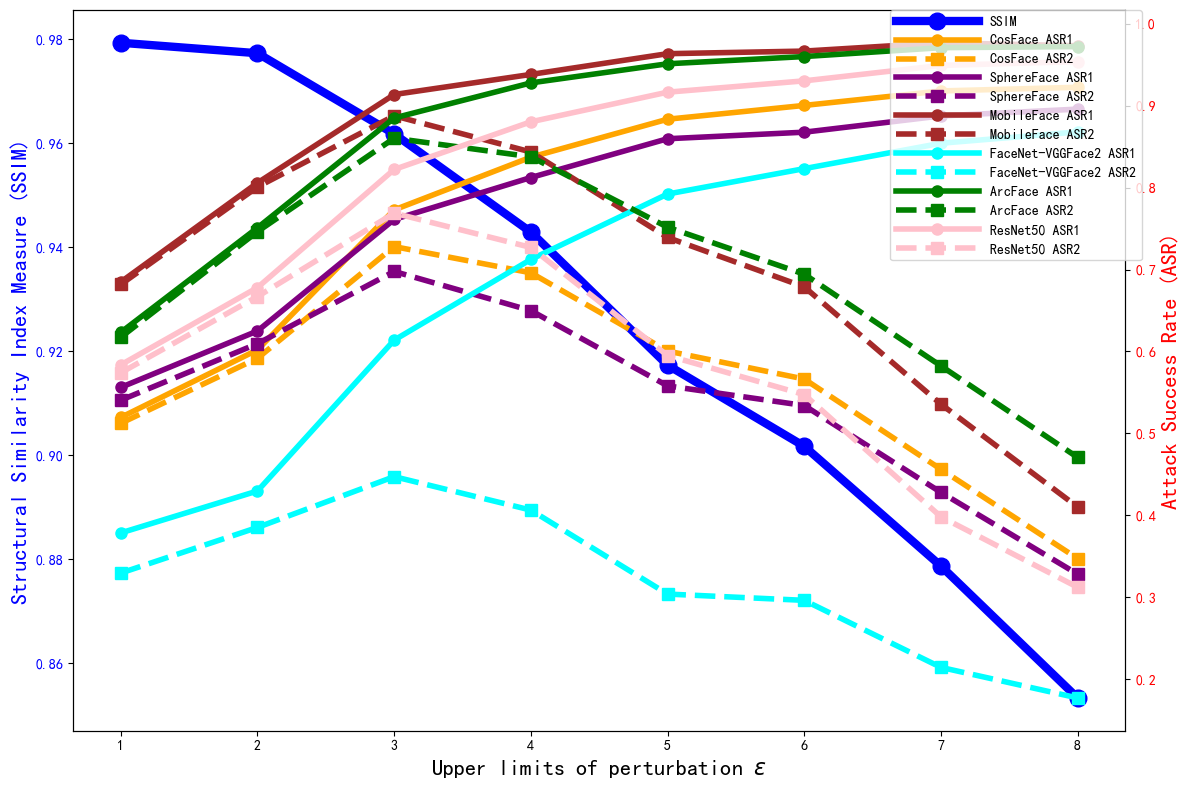

In [3]:
/# 不同扰动强度科赛下的攻击性与隐蔽性关系
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt

# 设置中文字体和负号显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 模拟从字典中读取的攻击数据
attack_data = evaluation_results

# 提取扰动强度
wostloss_models = ['target 1 8白盒 无stloss 990',
                   'target 2 8白盒 无stloss 990',
                   'target 3 8白盒 无stloss 990',
                   'target 4 8白盒 无stloss 990',
                   'target 5 8白盒 无stloss 990',
                   'target 6 8白盒 无stloss 990',
                   'target 7 8白盒 无stloss 990',
                   'target 8 8白盒 无stloss 990',]
x_index = [int(s[7]) for s in wostloss_models]
# 创建一个图形对象和一个子图对象
fig, ax1 = plt.subplots(figsize=(12, 8))


colors = [
    'orange',      # 橙色
    'purple',      # 紫色
    'brown',       # 棕色
    'cyan',        # 青色
    'green',      # 黄色
    "pink",        # 粉色
    'red',         # 红色
    'blue',        # 蓝色
    'yellow',       # 绿色
]
markers = ['o', 's', '^', 'D', 'P', 'H', 'X', 'v', '<']  # 圆形、方形、三角形等

# 绘制SSIM曲线
average_ssim = [np.mean(attack_data[atk_model]['ArcFace']['average_ssim']) for atk_model in wostloss_models]
ax1.plot(x_index, average_ssim, color='b', marker='o', linestyle='-', linewidth=6, label=f'SSIM', markersize=12)

# 设置左侧Y轴（SSIM）
ax1.set_xlabel('Upper limits of perturbation $\\epsilon$', fontsize=16)
ax1.set_ylabel('Structural Similarity Index Measure (SSIM)', color='b', fontsize=16)
ax1.tick_params(axis='y', labelcolor='b')

# 创建右侧Y轴并绘制ASR曲线
ax2 = ax1.twinx()
for idx, fr_model_name in enumerate(target_model_name_list[:-3]):
    attack_success_rate1 = [attack_data[atk_model][fr_model_name]['attack_success_rate1'] for atk_model in wostloss_models]
    attack_success_rate2 = [attack_data[atk_model][fr_model_name]['attack_success_rate2'] for atk_model in wostloss_models]
    # attack_success_rate3 = [attack_data[atk_model][fr_model_name]['attack_success_rate3'] for atk_model in wostloss_models]

    # 使用不同的颜色和标记绘制三条曲线，分别对应不同的攻击成功率
    ax2.plot(x_index, attack_success_rate1, color=colors[idx % len(colors)], marker=markers[0], linestyle='-', linewidth=4, label=f'{fr_model_name} ASR1', markersize=8)
    ax2.plot(x_index, attack_success_rate2, color=colors[idx % len(colors)], marker=markers[1], linestyle='--', linewidth=4, label=f'{fr_model_name} ASR2', markersize=8)
    # ax2.plot(x_index, attack_success_rate3, color=colors[idx % len(colors)], marker=markers[2], linestyle=':', linewidth=4, label=f'{fr_model_name} ASR3', markersize=8)

# 设置右侧Y轴（ASR）
ax2.set_ylabel('Attack Success Rate (ASR)', color='r', fontsize=16)
ax2.tick_params(axis='y', labelcolor='r')

# 添加图例
fig.tight_layout()
fig.legend(loc='upper left', bbox_to_anchor=(0.74, 0.99), handlelength=6)

# 保存图表为 PNG 文件
os.makedirs("./pic/", exist_ok=True)
plt.savefig('./pic/Figure_6.png', format='png', dpi=300)

# 显示图形
plt.show()

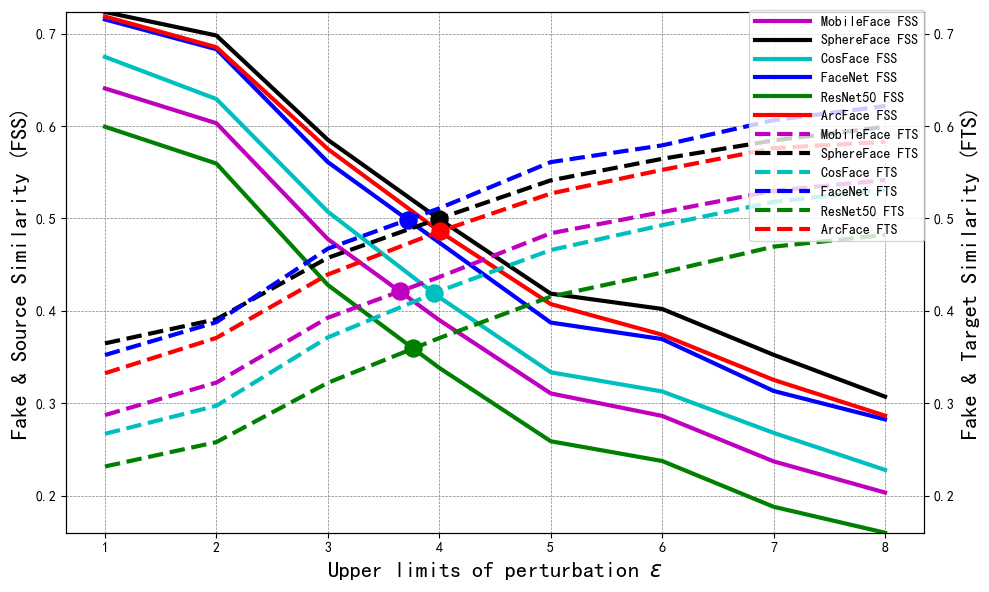

In [4]:
# 进一步说明科赛怎么选取的 为什么选4或5
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np

# Set font and avoid negative sign display issues
plt.rcParams['font.sans-serif'] = ['SimHei']  # Set font to SimHei for Chinese characters
plt.rcParams['axes.unicode_minus'] = False  # Solve the issue with negative sign display

# Simulated attack data from a dictionary
attack_data = evaluation_results  # Replace with actual data

# Extract perturbation strengths
wostloss_models = ['target 1 8白盒 无stloss 990',
                   'target 2 8白盒 无stloss 990',
                   'target 3 8白盒 无stloss 990',
                   'target 4 8白盒 无stloss 990',
                   'target 5 8白盒 无stloss 990',
                   'target 6 8白盒 无stloss 990',
                   'target 7 8白盒 无stloss 990',
                   'target 8 8白盒 无stloss 990',]
x_index = [int(s[7]) for s in wostloss_models]

# Extract mean_target_simi and mean_source_simi for each model
mean_target_simi_mobileface = [np.mean(attack_data[atk_model]['MobileFace']['mean_target']) for atk_model in wostloss_models]
mean_source_simi_mobileface = [np.mean(attack_data[atk_model]['MobileFace']['mean_source']) for atk_model in wostloss_models]

mean_target_simi_sphereface = [np.mean(attack_data[atk_model]['SphereFace']['mean_target']) for atk_model in wostloss_models]
mean_source_simi_sphereface = [np.mean(attack_data[atk_model]['SphereFace']['mean_source']) for atk_model in wostloss_models]

mean_target_simi_cosface = [np.mean(attack_data[atk_model]['CosFace']['mean_target']) for atk_model in wostloss_models]
mean_source_simi_cosface = [np.mean(attack_data[atk_model]['CosFace']['mean_source']) for atk_model in wostloss_models]

mean_target_simi_facenet = [np.mean(attack_data[atk_model]['FaceNet-VGGFace2']['mean_target']) for atk_model in wostloss_models]
mean_source_simi_facenet = [np.mean(attack_data[atk_model]['FaceNet-VGGFace2']['mean_source']) for atk_model in wostloss_models]

mean_target_simi_resnet = [np.mean(attack_data[atk_model]['ResNet50']['mean_target']) for atk_model in wostloss_models]
mean_source_simi_resnet = [np.mean(attack_data[atk_model]['ResNet50']['mean_source']) for atk_model in wostloss_models]

mean_target_simi_arcface = [np.mean(attack_data[atk_model]['ArcFace']['mean_target']) for atk_model in wostloss_models]
mean_source_simi_arcface = [np.mean(attack_data[atk_model]['ArcFace']['mean_source']) for atk_model in wostloss_models]

# Define a dictionary to manage data for all models
models = {
    "MobileFace": {
        'th_lfw': attack_data['target 1 8白盒 无stloss 990']['MobileFace']['threshold'],
        "FSS": mean_source_simi_mobileface,
        "FTS": mean_target_simi_mobileface,
        "color": "m",
    },
    "SphereFace": {
        'th_lfw': attack_data['target 1 8白盒 无stloss 990']['SphereFace']['threshold'],
        "FSS": mean_source_simi_sphereface,
        "FTS": mean_target_simi_sphereface,
        "color": "k",
    },
    "CosFace": {
        'th_lfw': attack_data['target 1 8白盒 无stloss 990']['CosFace']['threshold'],
        "FSS": mean_source_simi_cosface,
        "FTS": mean_target_simi_cosface,
        "color": "c",
    },
    "FaceNet": {
        'th_lfw': attack_data['target 1 8白盒 无stloss 990']['FaceNet-VGGFace2']['threshold'],
        "FSS": mean_source_simi_facenet,
        "FTS": mean_target_simi_facenet,
        "color": "b",
    },
    "ResNet50": {
        'th_lfw': attack_data['target 1 8白盒 无stloss 990']['ResNet50']['threshold'],
        "FSS": mean_source_simi_resnet,
        "FTS": mean_target_simi_resnet,
        "color": "g",
    },
    "ArcFace": {
        'th_lfw': attack_data['target 1 8白盒 无stloss 990']['ArcFace']['threshold'],
        "FSS": mean_source_simi_arcface,
        "FTS": mean_target_simi_arcface,
        "color": "r",
    },
}

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Create secondary axis for MTS
ax2 = ax1.twinx()

# After plotting both FSS and FTS
# Calculate the combined range of all values
all_y_values = []
for model, data in models.items():
    all_y_values.extend(data["FSS"])
    all_y_values.extend(data["FTS"])

# Find the min and max values from all_y_values
y_min = min(all_y_values)
y_max = max(all_y_values)

# Set the y-limits of both axes to be the same
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

# Add grid lines for better readability
ax1.grid(color='gray', linestyle='--', linewidth=0.5)

# Store intersection points for each model
intersection_points = {}

# Generate wave pattern
def generate_wave_line(y_value, x_range, num_points=100, amplitude=0.005):
    x = np.linspace(min(x_range), max(x_range), num_points)
    y = y_value + amplitude * np.sin(2 * np.pi * np.linspace(0, 3, num_points))  # 3 cycles
    return x, y

# Plot data for each model
for model, data in models.items():
    FSS = data["FSS"]
    FTS = data["FTS"]
    color = data["color"]
    
    # Plot MSS (source similarity) on the primary axis
    ax1.plot(x_index, FSS, f'{color}-', marker='', linewidth=3,zorder=2, label=f'{model} FSS') # marker='^',
    # Plot MTS (target similarity) on the secondary axis
    ax2.plot(x_index, FTS, f'{color}--', marker='', linewidth=3,zorder=2, label=f'{model} FTS') # marker='s', 
    # th_lfw 
    # ax1.plot(x_index, [data["th_lfw"]]*len(x_index), linestyle=':', color=color, linewidth=3, zorder=2, label=f'{model} threshold')

# 最后绘制交点避免被覆盖
for model, data in models.items():
    FSS = data["FSS"]
    FTS = data["FTS"]
    color = data["color"]
    # Find intersection points
    for i in range(len(x_index) - 1):
        if (FSS[i] - FTS[i]) * (FSS[i + 1] - FTS[i + 1]) < 0:  # Check if intersection exists
            # Linear interpolation formula for x_intersect
            x_intersect = (
                x_index[i] * (FTS[i + 1] - FSS[i + 1])
                - x_index[i + 1] * (FTS[i] - FSS[i])
            ) / ((FTS[i + 1] - FSS[i + 1]) - (FTS[i] - FSS[i]))
            # Linear interpolation formula for y_intersect
            y_intersect = FSS[i] + (x_intersect - x_index[i]) * (FSS[i + 1] - FSS[i]) / (x_index[i + 1] - x_index[i])
            # Save the intersection point
            intersection_points[model] = (x_intersect, y_intersect)
            # Highlight the intersection with a marker that has an internal hollow circle
            ax1.scatter(
                x_intersect,
                y_intersect,
                color=color,         # Outer circle color
                edgecolors=color,    # Border color
                s=150,               # Size of the marker
                zorder=5
            )
            continue

# Set axis labels
ax1.set_xlabel('Upper limits of perturbation $\\epsilon$', fontsize=16)
ax1.set_ylabel('Fake & Source Similarity (FSS)', fontsize=16)
ax1.tick_params(axis='y')

ax2.set_ylabel('Fake & Target Similarity (FTS)', fontsize=16)
ax2.tick_params(axis='y')

# 添加图例
fig.tight_layout()
fig.legend(loc='upper left', bbox_to_anchor=(0.747, 0.99), handlelength=4)
# 保存图表为 PNG 文件
os.makedirs("./pic/", exist_ok=True)
plt.savefig('./pic/Figure_7.png', format='png', dpi=300)

# Show the plot
plt.show()


In [5]:
import re

def get_visual_length(s):
    """计算字符串的视觉宽度：中文字符占2个位置，英文字符和数字占1个位置"""
    visual_length = 0
    for char in s:
        if char=='.':
            visual_length += 1
        if re.match(r'[\u4e00-\u9fa5]', char):  # 判断是否为中文字符
            visual_length += 2  # 中文字符占2个位置
        elif char.isdigit() or char.isalpha():  # 判断是否为数字或字母（大小写字母）
            visual_length += 1  # 英文字符和数字占1个位置
        else:
            visual_length += 1  # 其他字符（如标点符号、空格等）算作1个位置
    return visual_length

def align_string(s, fixed_length, alignment='left'):
    visual_length = get_visual_length(s)
    if visual_length < fixed_length:
        spaces = fixed_length - visual_length
        if alignment == 'left':
            return f"{s}{' ' * spaces}"  # 左对齐，右侧填充空格
        elif alignment == 'right':
            return f"{' ' * spaces}{s}"  # 右对齐，左侧填充空格
        elif alignment == 'center':
            left_space = spaces // 2
            right_space = spaces - left_space
            return f"{' ' * left_space}{s}{' ' * right_space}"  # 居中对齐
        else:
            raise ValueError("Invalid alignment type. Choose 'left', 'right', or 'center'.")
    else:
        return s  # 如果字符串已经超过目标宽度，则不做任何处理

In [8]:
import re
def model_name_format(models):
    res_models=[]
    for model in models:
       # 定义匹配规则
        a_match = re.search(r'target (\d+)', model)
        b_match = re.search(r'(\d+)ssim', model)
        c_match = re.search(r'双身份损失([\d.]+)', model)
        # 提取匹配到的内容
        a = r'$\epsilon$='+f"{a_match.group(1)}"
        b = r'$\zeta$='+f"{int(b_match.group(1))*0.01:.2f}" if b_match else r'w.o.$\zeta$'
        c = r'$\eta$='+f"{c_match.group(1)}" if c_match else r'w.o.$\eta$'
        res_models.append(f'{a} {b} {c}')
    return res_models

def show_adv_metrics_table(models, frmodel_name = "ArcFace"):
    formated_models = model_name_format(models)
    FTSs = []
    FSSs = []
    max_len=int(max(get_visual_length(model_name) for model_name in models ))
    print(" " * (max_len-6),'\ttrue_pert\tssim\tpsnr\tmse\tASR1\tASR2\tFSS & FTS')
    for idx,model in enumerate(models):
        print(f"{align_string(model, max_len, alignment='right')}:\t{np.mean(evaluation_results[model][frmodel_name]['true_pert']):.2f}\t{np.mean(evaluation_results[model][frmodel_name]['average_ssim'])*100:.2f}\t{np.mean(evaluation_results[model][frmodel_name]['average_psnr']):.2f}\t{np.mean(evaluation_results[model][frmodel_name]['average_mse']):.2f}\t{evaluation_results[model][frmodel_name]['attack_success_rate1']*100:.2f}\t{evaluation_results[model][frmodel_name]['attack_success_rate2']*100:.2f}\t{np.mean(evaluation_results[model][frmodel_name]['mean_source'])*100:.2f} & {np.mean(evaluation_results[model][frmodel_name]['mean_target'])*100:.2f}")
        FTSs.append(evaluation_results[model][frmodel_name]['mean_target'])
        FSSs.append(evaluation_results[model][frmodel_name]['mean_source'])
    return FTSs,FSSs

def show_adv_sample_plt(models,frmodel_name = "ArcFace"):
    formated_models = model_name_format(models)
    FTSs,FSSs=show_adv_metrics_table(models=models,frmodel_name = frmodel_name) 
    # 创建图形
    fig, ax = plt.subplots(figsize=(8, 8))
    # 绘制 FTS 对 FSS 的散点图
    for idx,model in enumerate(models):
        ax.scatter(FTSs[idx], FSSs[idx], color=colors[idx%len(colors)], label=formated_models[idx], s=10)
        centroid_x = np.mean(FTSs[idx])
        centroid_y = np.mean(FSSs[idx])
        # 计算点到质心的平均距离
        distances = np.sqrt((FTSs[idx] - centroid_x)**2 + (FSSs[idx] - centroid_y)**2)
        mean_distance = np.mean(distances)
        ax.scatter(
        centroid_x,
        centroid_y,
        color=colors[idx%len(colors)],         # Outer circle color
        edgecolors='g',    # Border color colors[idx%len(colors)]
        linewidths=3,
        s=2000*mean_distance,               # Size of the marker
        zorder=5)
    # 绘制 x = th_lfw 和 y = th_lfw 阈值线
    th_lfw=threshold_lfw[frmodel_name]['cos']
    ax.axvline(x=th_lfw, color='r', linestyle='--', linewidth=3, label=f'x = {th_lfw:.4f} ({frmodel_name} Threshold)')
    ax.axhline(y=th_lfw, color='g', linestyle='--', linewidth=3, label=f'y = {th_lfw:.4f} ({frmodel_name} Threshold)')
    
    # 绘制 y = x 的函数线
    x = np.linspace(-0.1, 1, 10)
    y = x  # y = x
    plt.plot(x, y, color='b', label="y = x", linewidth=3)
    
    plt.xlim(-0.1, 1)
    plt.ylim(-0.1, 1)
    
    
    # 设置坐标轴标签
    ax.set_xlabel('Fake & Target Similarity (FTS)', fontsize=14)
    ax.set_ylabel('Fake & Source Similarity (FSS)', fontsize=14)
    # 设置图例
    fig.legend(loc='upper left', bbox_to_anchor=(0.475, 0.89), handlelength=6, markerscale=3.0)
    # fig.legend(loc='upper right')

    # 保存图表为 PNG 文件
    os.makedirs("./pic/", exist_ok=True)
    plt.savefig('./pic/temp.png', format='png', dpi=100)
    # 显示图形
    plt.show()


                      	true_pert	ssim	psnr	mse	ASR1	ASR2	FSS & FTS
target 1 8白盒 无stloss 990:	1.84	97.93	40.37	6.19	62.33	61.73	71.84 & 33.24
target 8 8白盒 无stloss 990:	7.81	85.33	27.58	104.63	97.22	47.07	28.65 & 58.28


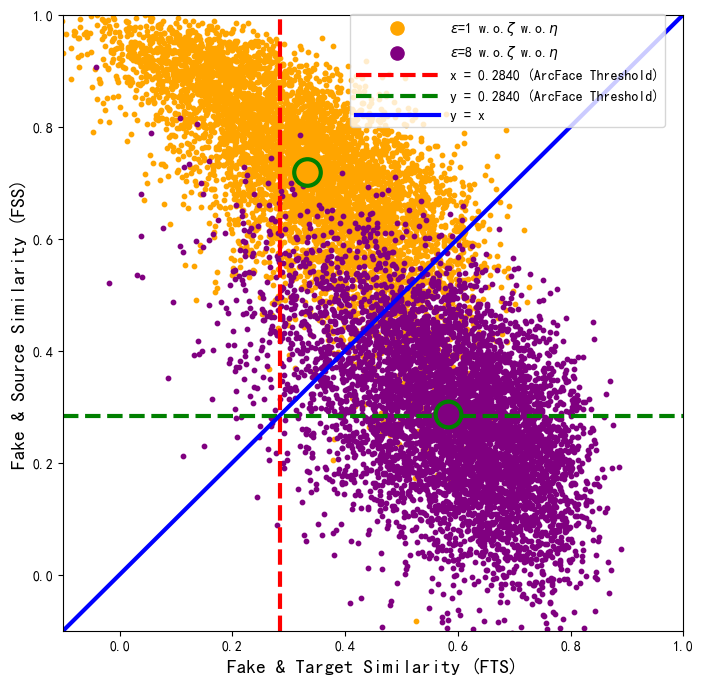

In [54]:
# 科赛18
show_adv_sample_plt(models=[
    'target 1 8白盒 无stloss 990',
    'target 8 8白盒 无stloss 990',
],frmodel_name = "ArcFace")

                      	true_pert	ssim	psnr	mse	ASR1	ASR2	FSS & FTS
target 4 8白盒 无stloss 990:	4.00	94.29	33.30	27.55	92.78	83.77	48.60 & 48.58


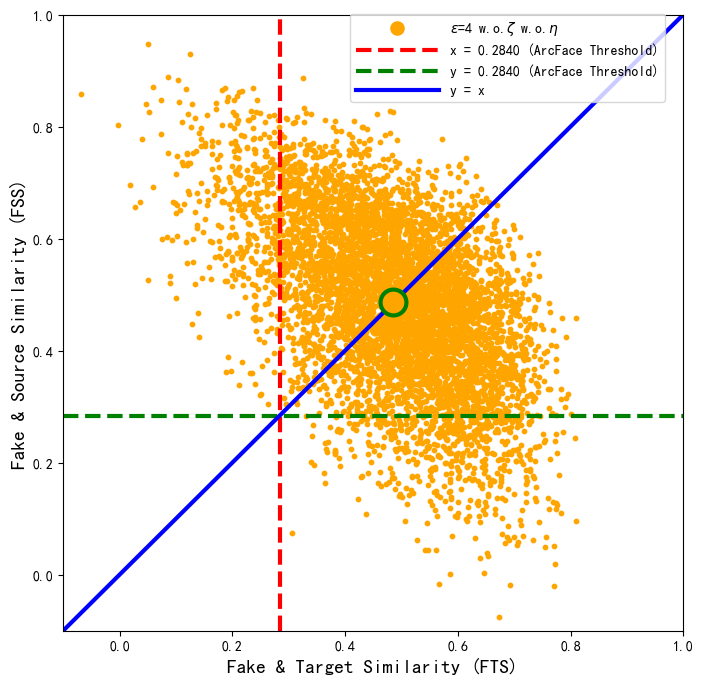

In [55]:
# 科赛4
show_adv_sample_plt(models=[
    'target 4 8白盒 无stloss 990',
],frmodel_name = "ArcFace")

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import os
import re

# 全局样式配置
plt.style.use('seaborn-v0_8')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'font.family': 'DejaVu Sans'
})

def model_name_format(models):
    res_models = []
    for model in models:
        a_match = re.search(r'target (\d+)', model)
        b_match = re.search(r'(\d+)ssim', model)
        c_match = re.search(r'双身份损失([\d.]+)', model)
        
        a = r'$\epsilon$='+f"{a_match.group(1)}" if a_match else ''
        b = r'$\zeta$='+f"{int(b_match.group(1))*0.01:.2f}" if b_match else ''
        c = r'$\eta$='+f"{c_match.group(1)}" if c_match else ''
        res_models.append(f'{a} {b} {c}'.strip())
    return res_models

def show_adv_metrics_table(models, frmodel_name):
    # 假设已定义 evaluation_results 和 threshold_lfw
    formated_models = model_name_format(models)
    FTSs = []
    FSSs = []
    for model in models:
        FTSs.append(evaluation_results[model][frmodel_name]['mean_target'])
        FSSs.append(evaluation_results[model][frmodel_name]['mean_source'])
    return FTSs, FSSs

def show_adv_sample_subplot(models, frmodel_name, ax):
    FTSs, FSSs = show_adv_metrics_table(models, frmodel_name)
    
    # 绘制数据点
    for idx, (fts, fss) in enumerate(zip(FTSs, FSSs)):
        ax.scatter(fts, fss, 
                 color=colors[idx%len(colors)],
                 s=12,          # 紧凑尺寸
                 edgecolor='w',
                 linewidth=0.3,
                 alpha=0.8,
                 zorder=2)
        
        # 绘制质心
        centroid = (np.mean(fts), np.mean(fss))
        ax.scatter(*centroid,
                 color=colors[idx%len(colors)],
                 s=80,         # 缩小质心尺寸
                 edgecolor='gold',
                 linewidth=1,
                 zorder=3,
                 alpha=0.9)

    # 参考线
    th = threshold_lfw[frmodel_name]['cos']
    ax.axvline(th, color='r', linestyle=':', linewidth=1.2, alpha=0.8)
    ax.axhline(th, color='g', linestyle=':', linewidth=1.2, alpha=0.8)
    ax.plot([0,1], [0,1], color='b', linewidth=1.2, alpha=0.6)
    
    # 标注
    ax.set_xlim(-0.25, 1)
    ax.set_ylim(-0.25, 1)
    ax.set_title(frmodel_name, pad=8)
    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal')

def plot_compact_grid(models):
    fig, axs = plt.subplots(2, 3, figsize=(9.5, 6.2))  # A4纸双栏适配尺寸
    
    model_grid = [
        ('ArcFace', axs[0,0]),
        ('ResNet50', axs[0,1]), 
        ('FaceNet-VGGFace2', axs[0,2]),
        ('CosFace', axs[1,0]),
        ('SphereFace', axs[1,1]),
        ('MobileFace', axs[1,2])
    ]

    for frmodel, ax in model_grid:
        show_adv_sample_subplot(models, frmodel, ax)

    # 统一图例
    handles = [
        plt.Line2D([0], [0], marker='o', color=colors[i], 
                 markersize=6, linestyle='', alpha=0.8)
        for i in range(len(models))
    ]
    labels = model_name_format(models)
    
    # fig.legend(handles, labels,
    #          loc='upper center',
    #          ncol=2,
    #          bbox_to_anchor=(0.5, 1.02),
    #          frameon=True,
    #          framealpha=0.9,
    #          title='Model Configurations',
    #          title_fontsize=8)

    plt.tight_layout()
    plt.subplots_adjust(top=0.88, hspace=0.3, wspace=0.25)
    
    # 保存输出
    os.makedirs('./pic', exist_ok=True)
    plt.savefig('./pic/compact_analysis.png', 
              dpi=300, 
              bbox_inches='tight',
              facecolor='white')
    plt.close()

# 使用示例
# 假设已定义 evaluation_results 和 threshold_lfw
plot_compact_grid(models=[
    'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 2490'
])

In [11]:
# kesai
models=[
    'target 5 8白盒 无stloss 990',
    'target 5 8白盒 92ssim 990',
    'target 5 8白盒 无stloss 双身份损失0.15 990',
    'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 990',
]
# CosFace SphereFace MobileFace FaceNet-VGGFace2 ArcFace ResNet50 testir152
fr_model_name = "FaceNet-VGGFace2"
FTSs,FSSs = show_adv_metrics_table(models=models,frmodel_name = fr_model_name)

                                             	true_pert	ssim	psnr	mse	ASR1	ASR2	FSS & FTS
                       target 5 8白盒 无stloss 990:	5.01	91.73	31.32	43.30	79.22	30.38	38.73 & 56.09
                         target 5 8白盒 92ssim 990:	4.50	94.50	32.38	34.92	75.48	39.33	45.57 & 53.09
       target 5 8白盒 无stloss 双身份损失0.15 990:	4.95	92.72	31.46	42.16	75.48	42.25	47.82 & 53.36
target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 990:	4.41	94.62	32.57	33.72	70.57	43.92	51.76 & 50.96


                                              	true_pert	ssim	psnr	mse	ASR1	ASR2	FSS & FTS
                        target 1 8白盒 无stloss 990:	1.84	97.93	40.37	6.19	62.33	61.73	71.84 & 33.24
                        target 2 8白盒 无stloss 990:	2.11	97.72	38.86	7.70	75.10	74.63	68.52 & 37.07
                        target 3 8白盒 无stloss 990:	3.01	96.17	35.78	15.56	88.50	86.03	57.50 & 43.93
                        target 4 8白盒 无stloss 990:	4.00	94.29	33.30	27.55	92.78	83.77	48.60 & 48.58
                        target 5 8白盒 无stloss 990:	5.01	91.73	31.34	43.33	95.12	75.17	40.73 & 52.69
                        target 6 8白盒 无stloss 990:	5.85	90.17	30.02	58.84	96.00	69.43	37.41 & 55.24
                        target 7 8白盒 无stloss 990:	6.92	87.87	28.53	82.52	97.08	58.23	32.52 & 57.60
                        target 8 8白盒 无stloss 990:	7.81	85.33	27.58	104.63	97.22	47.07	28.65 & 58.28
target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 3440:	4.43	94.72	32.44	34.26	93.53	88.37	52.68 & 50.69


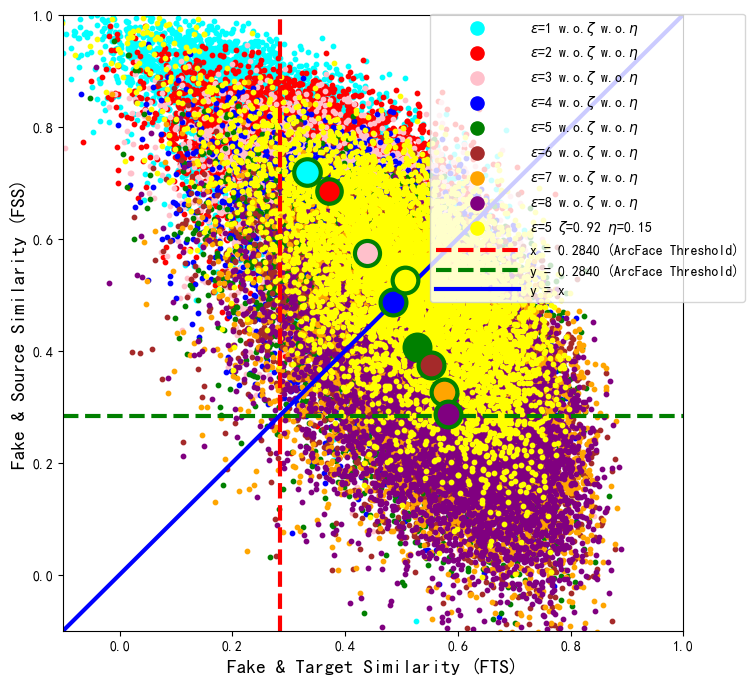

In [9]:
# kesai 对比
colors = [
    'cyan',        # 青色
    'red',      # 黄色
    "pink",        # 粉色
    'blue',        # 蓝色
    'green',       # 绿色
    'brown',         # 红色
    'orange',      # 橙色
    'purple',      # 紫色
    'yellow',       # 棕色
]
models=[
    'target 1 8白盒 无stloss 990',
    'target 2 8白盒 无stloss 990',
    'target 3 8白盒 无stloss 990',
    'target 4 8白盒 无stloss 990',
    'target 5 8白盒 无stloss 990',
    'target 6 8白盒 无stloss 990',
    'target 7 8白盒 无stloss 990',
    'target 8 8白盒 无stloss 990',
    'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 3440',
]
# CosFace SphereFace MobileFace FaceNet-VGGFace2 ArcFace ResNet50 testir152
fr_model_name = "ArcFace"
show_adv_sample_plt(models=models,frmodel_name = fr_model_name)

In [14]:
# 原始身份损失
colors = [
    'yellow',        # 蓝色
]
models=[
   'target 5 8白盒 无stloss 990',
   'target 5 8白盒 无stloss 双身份损失0.15 990',
    'target 5 8白盒 92ssim 990',
   'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 990',
]
# CosFace SphereFace MobileFace FaceNet-VGGFace2 ArcFace ResNet50 testir152
fr_model_name = "FaceNet-VGGFace2"
FTSs,FSSs = show_adv_metrics_table(models=models,frmodel_name = fr_model_name)

                                             	true_pert	ssim	psnr	mse	ASR1	ASR2	FSS & FTS
                       target 5 8白盒 无stloss 990:	5.01	91.73	31.32	43.30	79.22	30.38	38.73 & 56.09
       target 5 8白盒 无stloss 双身份损失0.15 990:	4.95	92.72	31.46	42.16	75.48	42.25	47.82 & 53.36
                         target 5 8白盒 92ssim 990:	4.50	94.50	32.38	34.92	75.48	39.33	45.57 & 53.09
target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 990:	4.41	94.62	32.57	33.72	70.57	43.92	51.76 & 50.96


In [18]:
# ssim的消融实验
models=[
    'target 4 8白盒 无stloss 990',
    'target 4 8白盒 奇怪ssim 93ssim 990',
    'target 4 8白盒 奇怪ssim 97ssim 990',
    'target 5 8白盒 无stloss 990',
    'target 5 8白盒 92ssim 990',
    'target 5 8白盒 奇怪ssim 95ssim 990',
    'target 5 8白盒 无stloss 双身份损失0.15 990',
    'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 990',
    'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 2490',
]
# CosFace SphereFace MobileFace FaceNet-VGGFace2 ArcFace ResNet50 testir152
fr_model_name = "FaceNet-VGGFace2"
FTSs,FSSs=show_adv_metrics_table(models=models,frmodel_name = fr_model_name)

                                              	true_pert	ssim	psnr	mse	ASR1	ASR2	FSS & FTS
                        target 4 8白盒 无stloss 990:	4.00	94.32	33.32	27.55	71.23	40.63	47.39 & 51.09
                 target 4 8白盒 奇怪ssim 93ssim 990:	3.82	95.46	33.70	25.20	68.38	43.32	50.70 & 49.78
                 target 4 8白盒 奇怪ssim 97ssim 990:	3.49	96.33	34.65	21.13	64.12	42.15	53.86 & 47.57
                        target 5 8白盒 无stloss 990:	5.01	91.73	31.32	43.30	79.22	30.38	38.73 & 56.09
                          target 5 8白盒 92ssim 990:	4.50	94.50	32.38	34.92	75.48	39.33	45.57 & 53.09
                 target 5 8白盒 奇怪ssim 95ssim 990:	3.97	95.62	33.52	27.80	69.53	38.30	48.41 & 50.23
        target 5 8白盒 无stloss 双身份损失0.15 990:	4.95	92.72	31.46	42.16	75.48	42.25	47.82 & 53.36
 target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 990:	4.41	94.62	32.57	33.72	70.57	43.92	51.76 & 50.96
target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 2490:	4.31	95.13	32.70	32.50	73.57	48.03	52.35 & 52.23


In [40]:
# 集成模型消融
models=[
    'target 5 1白盒 92ssim 原始身份损失0.15 1490', # ['FaceNet-VGGFace2']
    'target 5 4白盒 92ssim 原始身份损失0.15 1490', # ['FaceNet-VGGFace2','IR50-CosFace','IR50-ArcFace','IR50-SphereFace']
    'target 5 6白盒 92ssim 原始身份损失0.15 1490', # ['FaceNet-VGGFace2','Mobilenet-stride1','ShuffleNet_V1_GDConv','IR50-CosFace','IR50-ArcFace','IR50-SphereFace']
    'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 1490',
    'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 2490',
]
# CosFace SphereFace MobileFace FaceNet-VGGFace2 ArcFace ResNet50 testir152
fr_model_name = "MobileFace"
FTSs,FSSs = show_adv_metrics_table(models=models,frmodel_name = fr_model_name)

                                              	true_pert	ssim	psnr	mse	ASR1	ASR2	FSS & FTS
       target 5 1白盒 92ssim 原始身份损失0.15 1490:	4.49	95.01	32.35	34.77	70.58	69.80	51.36 & 27.57
       target 5 4白盒 92ssim 原始身份损失0.15 1490:	4.57	94.48	32.21	36.33	93.87	89.77	42.72 & 44.32
       target 5 6白盒 92ssim 原始身份损失0.15 1490:	4.56	94.37	32.26	36.11	94.08	89.78	43.33 & 45.79
target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 1490:	4.06	95.37	33.35	28.91	91.37	88.68	48.48 & 42.79
target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 2490:	4.31	95.17	32.71	32.52	93.88	91.65	46.34 & 44.79
